In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/sample_data.csv")

df.head()

,Customer_ID,Age,Income,Website_Visits,Time_On_Site,Purchase
0,C001,22,25000,2,5.2,No
1,C002,25,30000,3,6.1,No
2,C003,30,40000,4,7.5,No
3,C004,35,55000,6,10.2,Yes
4,C005,40,70000,7,12.5,Yes


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 30
Number of columns: 6

Column names:
['Customer_ID', 'Age', 'Income', 'Website_Visits', 'Time_On_Site', 'Purchase']

Data types:
Customer_ID           str
Age                 int64
Income              int64
Website_Visits      int64
Time_On_Site      float64
Purchase              str
dtype: object


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Customer_ID       0
Age               0
Income            0
Website_Visits    0
Time_On_Site      0
Purchase          0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df = df.drop_duplicates()

for column in df.select_dtypes(include="number").columns:
    df[column] = df[column].fillna(df[column].median())

print("Data cleaning completed!")

Data cleaning completed!


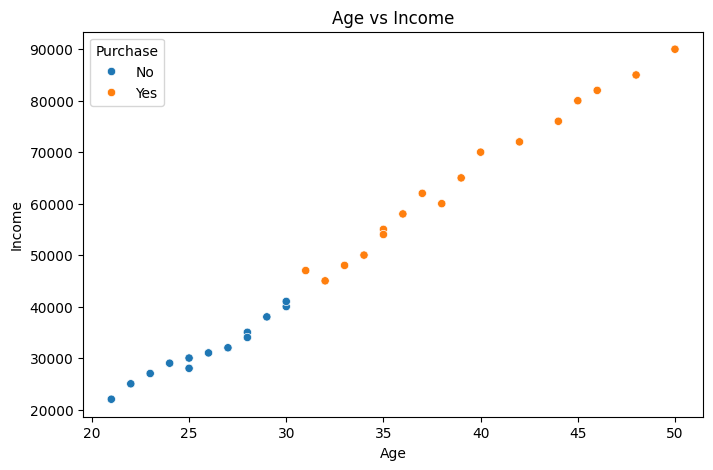

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Income",
    hue="Purchase"
)

plt.title("Age vs Income")
plt.xlabel("Age")
plt.ylabel("Income")

plt.show()

In [10]:
X = df.drop(columns=["Customer_ID", "Purchase"])
y = df["Purchase"]

In [11]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("No  =", encoder.transform(["No"])[0])
print("Yes =", encoder.transform(["Yes"])[0])

No  = 0
Yes = 1


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 24
Testing records: 6


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

results

{'Logistic Regression': 1.0, 'Decision Tree': 1.0, 'Random Forest': 1.0}

In [14]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df

,Model,Accuracy
0,Logistic Regression,100.0
1,Decision Tree,100.0
2,Random Forest,100.0
